# Machine Learning Phases of Matter in the 2D Ising Model

This notebook trains a neural network to distinguish ordered and disordered phases in the two-dimensional Ising model directly from raw spin configurations.

The workflow follows the approach introduced by Carrasquilla & Melko (2017), where machine learning is used to identify the phase transition from Monte Carlo-generated data.

## What this notebook does

1. Loads precomputed spin configurations generated externally with Fortran Monte Carlo simulations
2. Assigns phase labels based on temperature relative to the critical temperature
3. Trains a PyTorch neural network on clearly ordered and clearly disordered states
4. Evaluates the model across all temperatures, including the critical region
5. Computes the average probability that a configuration belongs to the ordered phase
6. Compares results across different lattice sizes
7. Performs finite-size scaling analysis and estimates the critical temperature

## Dataset Structure

Each spin configuration from the ising_sampler.f90 is stored as a flattened vector of spins:

```python
[-1, +1, -1, -1, +1, ...]
```

For a lattice of size:

```python
L x L
```

thus, each sample contains:

```python
L * L
```

spin values.

The network is trained as a binary classifier:

* Ordered phase -> label = 1
* Disordered phase -> label = 0
* Near-critical configurations are excluded from training but kept for evaluation

## Neural Network

The model is a simple fully connected feed-forward network:

```python
nn.Sequential(
    nn.Linear(L * L, 100),
    nn.Sigmoid(),
    nn.Linear(100, 2)
)
```

The output is interpreted as the probability that a given spin configuration belongs to the ordered phase.

## Physical results

The exact critical temperature of the 2D Ising model is:

```python
Tc = 2 / ln(1 + sqrt(2)) ≈ 2.269
```

The results of the trained nn show that: 

* High ordered probability at low temperature
* High disordered probability at high temperature
* A transition near the critical temperature
* Improved agreement with the exact Tc as the lattice size increases
* Finite-size scaling collapse across different lattice sizes


In [55]:

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import matplotlib as mpl
from tqdm import tqdm

import os

In [8]:
"""
load_ising_configs.py

Loads the binary configuration files produced by ising_sampler.f90
and assembles them into the dataset dict expected by the neural network code.

Usage
-----
   Use you own directory of data_dir on the main.
"""



def load_dataset(data_dir, L_list=None, T_list=None):
    """
    Read configs_index.dat and load every matching binary file.

    Parameters
    ----------
    data_dir : str
        Directory containing configs_index.dat and the .bin files.
    L_list   : list[int] or None
        If given, only load files whose L is in this list.
    T_list   : array-like or None
        If given, only load temperatures within 0.01 of a value in T_list.
        Pass None to load everything.

    Returns
    -------
    dataset : dict  keyed by L
        dataset[L] = {
            "configs" : float32 array  (N_total, L*L)   raw ±1 spins
            "labels"  : int64 array    (N_total,)        1=ordered, 0=disordered
            "temps"   : float32 array  (N_total,)        temperature of each config
        }

    Notes
    -----
    
    Fortran writes arrays in column-major (Fortran) order.
    We reshape to (L, L) with order='F' then flatten with order='C'
    to get the same row-major flat vector the network expects.

    Label convention (matches the paper):
        T < Tc - 0.6  → ordered     (label = 1)
        T > Tc + 0.7  → disordered  (label = 0)
        Otherwise     → label = -1  (near-Tc, exclude from training)
    """
    
    
    Tc = 2.269
    index_file = os.path.join(data_dir, "configs_index.dat")
    

    # ── Parse index ────────────────────────────────────────────────────────────────
    entries = []
    
    with open(index_file) as f:
        for line in f:
            
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split()
            fname     = parts[0]
            T         = float(parts[1])
            XS        = int(parts[2])
            YS        = int(parts[3])
            n_configs = int(parts[4])
            entries.append((fname, T, XS, YS, n_configs))

            
    # ── Group by L ─────────────────────────────────────────────────────────────────
    all_L = sorted(set(e[2] for e in entries))
    
    if L_list is not None:
        all_L = [L for L in all_L if L in L_list]

    dataset = {}

    for L in all_L:
        
        configs_list, labels_list, temps_list = [], [], []

        for fname, T, XS, YS, n_configs in entries:
            
            if XS != L:
                continue
            if T_list is not None:
                if not any(abs(T - t) < 0.01 for t in T_list):
                    continue

            # ── Assign label ───────────────────────────────────────────────────
            if T < Tc - 0.6:
                label = 1       # ordered
            elif T > Tc + 0.7:
                label = 0       # disordered
            else:
                label = -1      # near Tc — kept in dataset but flagged

            # ── Read binary file ───────────────────────────────────────────────
            path = os.path.join(data_dir, fname)
            raw  = np.fromfile(path, dtype=np.int8)          # flat int8 stream

            # Each config is XS*YS bytes; Fortran wrote column-major
            n_read = len(raw) // (XS * YS)
            if n_read < n_configs:
                print(f"  Warning: {fname} has {n_read} configs, expected {n_configs}")


            raw = raw[: n_read * XS * YS]

            # First split into separate configurations
            raw = raw.reshape(n_read, XS * YS)

            # Rebuild each config with Fortran ordering, then flatten in C order
            flat = np.empty((n_read, XS * YS), dtype=np.float32)

            for k in range(n_read):
                cfg = raw[k].reshape((XS, YS), order='F')
                flat[k] = cfg.reshape(XS * YS, order='C')
    
    
        
            configs_list.append(flat)
            labels_list.append(np.full(n_read, label,       dtype=np.int64))
            temps_list.append( np.full(n_read, T,           dtype=np.float32))

        if not configs_list:
            continue

        dataset[L] = {
            "configs": np.concatenate(configs_list, axis=0),
            "labels":  np.concatenate(labels_list,  axis=0),
            "temps":   np.concatenate(temps_list,   axis=0),
        }

        n_ord  = (dataset[L]["labels"] == 1).sum()
        n_dis  = (dataset[L]["labels"] == 0).sum()
        n_near = (dataset[L]["labels"] == -1).sum()
        print(f"  L={L:3d}: {len(dataset[L]['configs']):5d} configs  "
              f"(ordered={n_ord}, disordered={n_dis}, near-Tc={n_near})")

    return dataset


def train_test_split(dataset, L):
    
    """
    Convenience helper: returns X_train, y_train, X_test, y_test, T_test
    where train = configs far from Tc (labels 0 or 1)
          test  = all configs (for plotting output vs T)
    """
    
    d = dataset[L]
    train_mask = d["labels"] != -1

    X_train = d["configs"][train_mask]
    y_train = d["labels"][train_mask]

    X_test  = d["configs"]
    y_test  = d["labels"]
    T_test  = d["temps"]
    

    return X_train, y_train, X_test, y_test, T_test





In [13]:

class IsingNet(nn.Module):
    
    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 100),
            nn.Sigmoid(),
            nn.Linear(100, 2)
        )

    def forward(self, x):
        
        return self.net(x)
    

def train_network(L, dataset, device, epochs, batch_size, lr):
    
    """
    Train a network for a given system size L.
    Uses only configs with labels 0 or 1.
    """
    
    data = dataset[L]

    train_mask = data["labels"] != -1

    X_train = torch.tensor(
        data["configs"][train_mask], dtype=torch.float32
    )
    y_train = torch.tensor(
        data["labels"][train_mask], dtype=torch.long
    )

    loader = DataLoader(
        TensorDataset(X_train, y_train),
        batch_size=batch_size,
        shuffle=True,
    )

    model = IsingNet(L * L).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        if (epoch + 1) % 5 == 0:
            print(
                f"  L={L} epoch {epoch+1}/{epochs} "
                f"loss={total_loss / len(loader):.4f}"
            )

    return model

In [14]:




def get_output_vs_T(model, dataset, L, device, batch_size):
    
    """
    Average network output P(ordered) for each temperature.
    """
    model.eval()

    data = dataset[L]
    X_all = torch.tensor(data["configs"], dtype=torch.float32)
    T_all = data["temps"]

    with torch.no_grad():
        probs_all = []

        for i in range(0, len(X_all), batch_size):
            xb = X_all[i:i+batch_size].to(device)
            logits = model(xb)
            probs = torch.softmax(logits, dim=1)[:, 1]
            probs_all.append(probs.cpu())

        probs_all = torch.cat(probs_all).numpy()

    unique_temps = np.unique(T_all)
    outputs_mean = []

    for T in unique_temps:
        mask = np.isclose(T_all, T)
        outputs_mean.append(probs_all[mask].mean())

    return unique_temps, np.array(outputs_mean)



In [56]:
def main(epochs, batch_size, lr, data_dir):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    Tc_exact = 2.0 / np.log(1 + np.sqrt(2))
    print(f"Exact Tc/J = {Tc_exact:.4f}")

    print("\n[1/3] Loading precomputed configurations ...")
    dataset = load_dataset(data_dir)

    L_list = sorted(dataset.keys())

    print("\n[2/3] Training neural networks ...")
    models = {}
    outputs = {}
    temperature_axes = {}

    # dictionaries to save plotting data
    raw_curve_data = {}
    collapse_curve_data = {}

    for L in L_list:
        print(f"\nTraining for L = {L}")

        model = train_network(
            L,
            dataset,
            device,
            epochs,
            batch_size,
            lr,
        )

        models[L] = model

        T_vals, out_vals = get_output_vs_T(
            model,
            dataset,
            L,
            device,
            batch_size
        )

        temperature_axes[L] = T_vals
        outputs[L] = out_vals

        # raw T vs probability data
        raw_curve_data[f"L{L}"] = {
            "T": T_vals.copy(),
            "P_ordered": out_vals.copy(),
        }

        print(f"\nTemperature vs P(ordered) for L = {L}")
        print("-" * 40)
        print(f"{'T':>8} {'P(ordered)':>15}")

        for T, prob in zip(T_vals, out_vals):
            print(f"{T:8.3f} {prob:15.4f}")

    print("\n[3/3] Finite-size scaling ...")

    crossing_temps = {}
    L_pairs = [
        (L_list[i], L_list[i + 1])
        for i in range(len(L_list) - 1)
    ]

    for L1, L2 in L_pairs:
        T_common = temperature_axes[L1]

        T_cross = find_crossing_temperature(
            T_common,
            outputs[L1],
            outputs[L2],
        )

        if T_cross is not None:
            crossing_temps[(L1, L2)] = T_cross
            print(f"  T* for (L={L1}, L={L2}): {T_cross:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))


    colors = plt.cm.viridis(np.linspace(0, 1, len(L_list)))

    # --------------------------------------------------
    # Plot 1: Raw output vs temperature
    # --------------------------------------------------
    ax = axes[0]

    for L, c in zip(L_list, colors):
        ax.plot(
            temperature_axes[L],
            outputs[L],
            'o-',
            color=c,
            label=f"L={L}",
            ms=4,
        )

    ax.axvline(
        Tc_exact,
        color='orange',
        ls='--',
        lw=1.5,
        label='Exact $T_c$',
    )

    ax.set_xlabel("T / J")
    ax.set_ylabel("Average P(ordered)")
    ax.set_title("Averaged output layer vs T")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # --------------------------------------------------
    # Plot 2: Finite-size scaling collapse
    # --------------------------------------------------
    ax = axes[1]
    nu = 1.0

    for L, c in zip(L_list, colors):
        t = (temperature_axes[L] - Tc_exact) / Tc_exact
        x = t * L ** (1.0 / nu)

        # Save collapse data
        collapse_curve_data[f"L{L}"] = {
            "x_scaled": x.copy(),
            "P_ordered": outputs[L].copy(),
        }

        ax.plot(
            x,
            outputs[L],
            'o-',
            color=c,
            label=f"L={L}",
            ms=4,
        )

    ax.axvline(0, color='orange', ls='--', lw=1.5)
    ax.set_xlabel(r'$tL^{1/\nu}$')
    ax.set_ylabel('Average P(ordered)')
    ax.set_title('Data collapse')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    if crossing_temps:
        mean_Tc = np.mean(list(crossing_temps.values()))
        print(f"Estimated Tc/J = {mean_Tc:.4f}")

    return {
        "models": models,
        "temperature_axes": temperature_axes,
        "outputs": outputs,
        "raw_curve_data": raw_curve_data,
        "collapse_curve_data": collapse_curve_data,
        "crossing_temps": crossing_temps,
        "Tc_exact": Tc_exact,
    }

Using device: cpu
Exact Tc/J = 2.2692

[1/3] Loading precomputed configurations ...
  L= 20: 34000 configs  (ordered=9000, disordered=9000, near-Tc=16000)

[2/3] Training neural networks ...

Training for L = 20
  L=20 epoch 5/30 loss=0.0154
  L=20 epoch 10/30 loss=0.0108
  L=20 epoch 15/30 loss=0.0031
  L=20 epoch 20/30 loss=0.0274
  L=20 epoch 25/30 loss=0.0057
  L=20 epoch 30/30 loss=0.0058

Temperature vs P(ordered) for L = 20
----------------------------------------
       T      P(ordered)
   1.000          0.9992
   1.080          0.9999
   1.160          0.9999
   1.240          0.9999
   1.320          0.9999
   1.400          0.9999
   1.480          0.9991
   1.560          0.9991
   1.640          0.9992
   1.720          0.9976
   1.800          0.9973
   1.880          0.9828
   1.960          0.9789
   2.040          0.9441
   2.120          0.8523
   2.200          0.7005
   2.280          0.4679
   2.360          0.2504
   2.440          0.1325
   2.520          0.0611

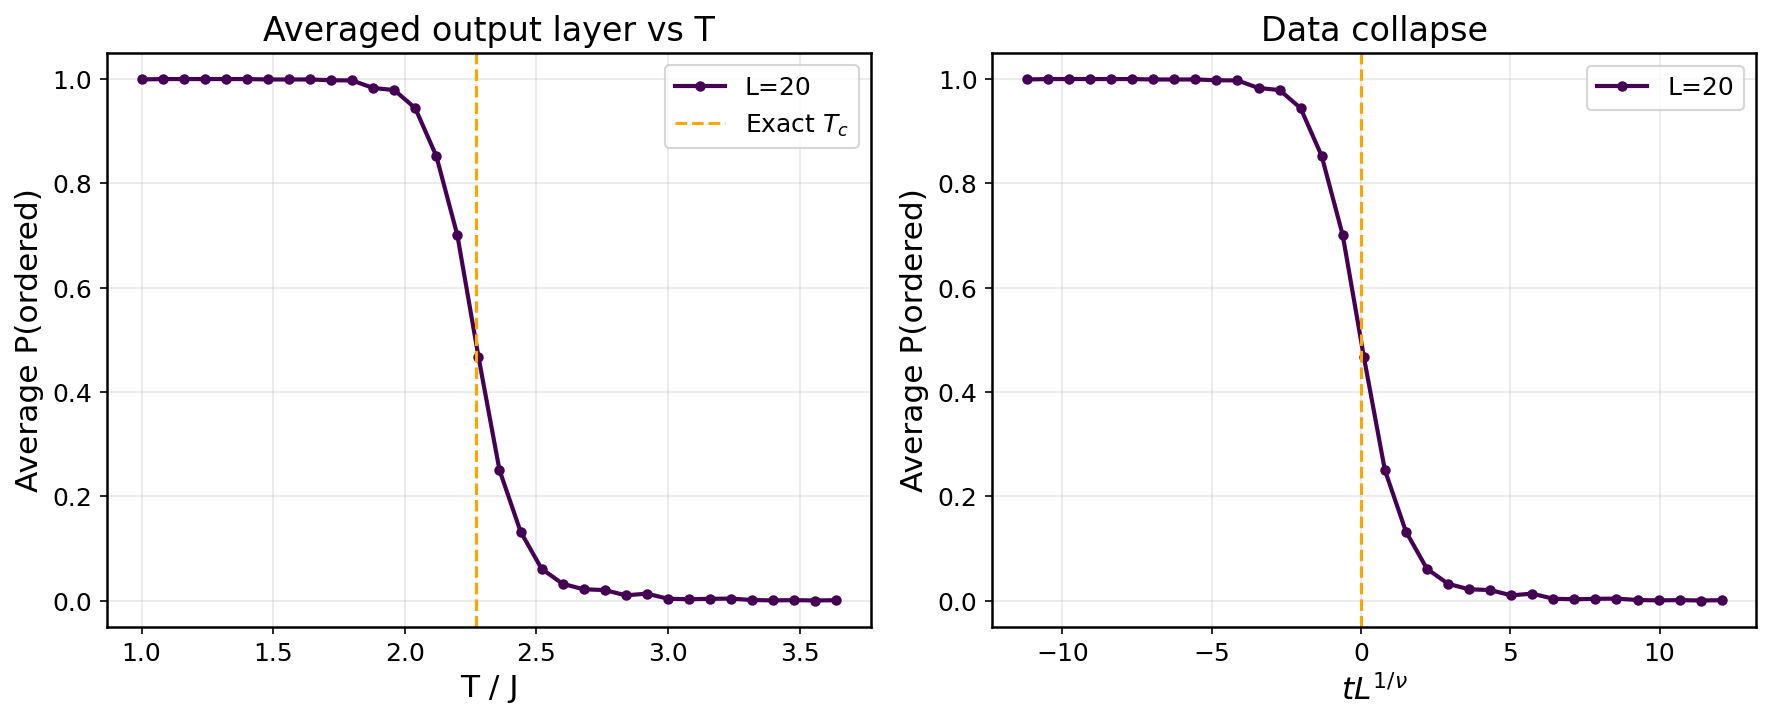

In [63]:
epochs = 30
batch_size = 64
lr = 6e-2
data_dir = r"path_lattice_size_20"

if __name__ == "__main__":
    dataL20 = main(epochs, batch_size, lr, data_dir)

Using device: cpu
Exact Tc/J = 2.2692

[1/3] Loading precomputed configurations ...
  L= 30: 34000 configs  (ordered=9000, disordered=9000, near-Tc=16000)

[2/3] Training neural networks ...

Training for L = 30
  L=30 epoch 5/45 loss=0.0019
  L=30 epoch 10/45 loss=0.0003
  L=30 epoch 15/45 loss=0.0001
  L=30 epoch 20/45 loss=0.0001
  L=30 epoch 25/45 loss=0.0000
  L=30 epoch 30/45 loss=0.0000
  L=30 epoch 35/45 loss=0.0000
  L=30 epoch 40/45 loss=0.0000
  L=30 epoch 45/45 loss=0.0000

Temperature vs P(ordered) for L = 30
----------------------------------------
       T      P(ordered)
   1.000          1.0000
   1.080          1.0000
   1.160          1.0000
   1.240          1.0000
   1.320          1.0000
   1.400          1.0000
   1.480          1.0000
   1.560          1.0000
   1.640          1.0000
   1.720          1.0000
   1.800          1.0000
   1.880          1.0000
   1.960          1.0000
   2.040          0.9979
   2.120          0.9745
   2.200          0.8972
   2.2

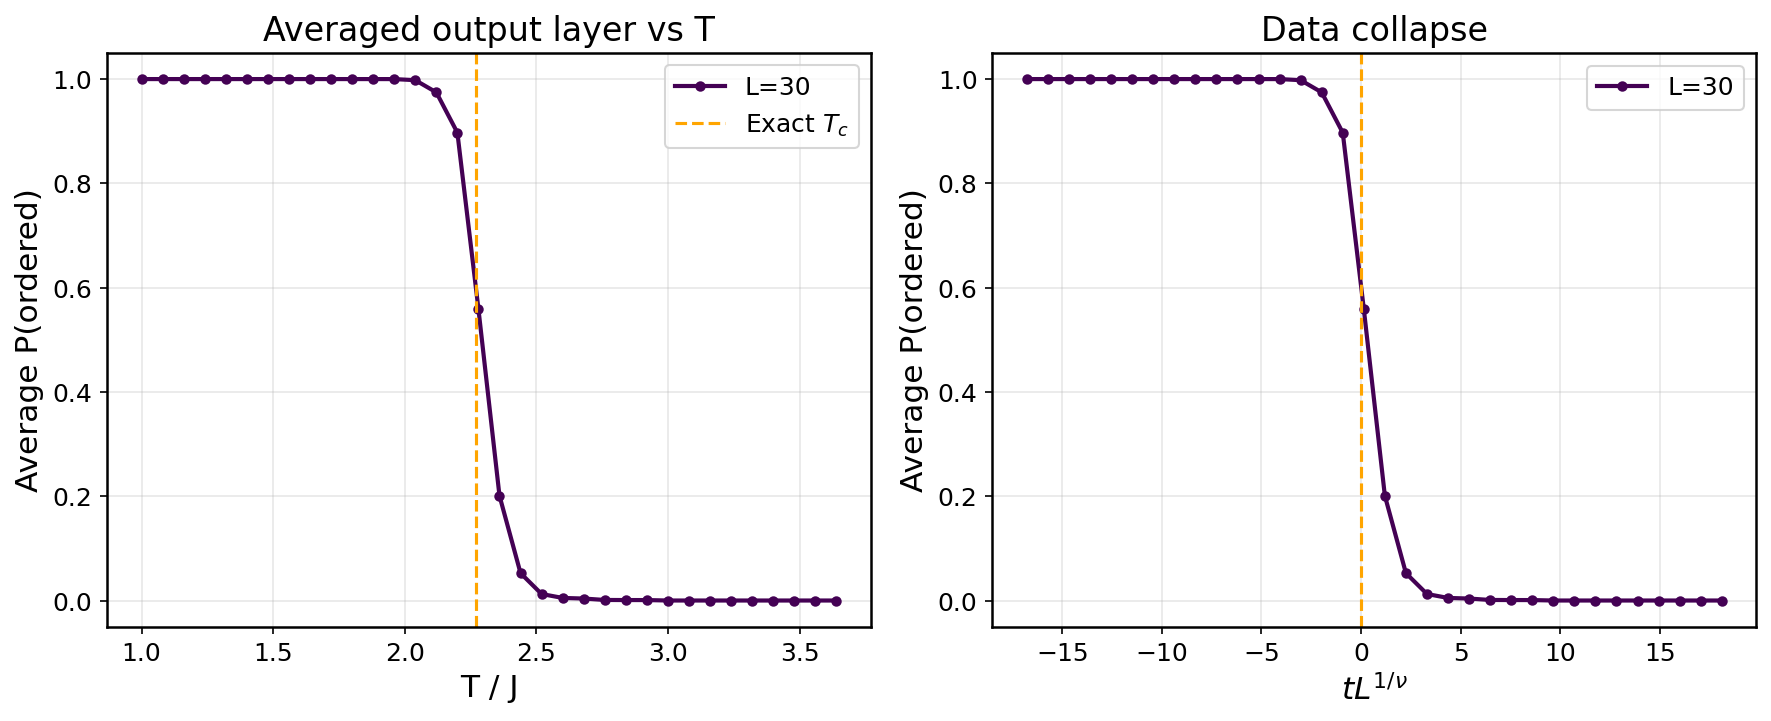

In [65]:
epochs = 45
batch_size = 128
lr = 2e-2
data_dir = r"path_lattice_size_30"

if __name__ == "__main__":
    dataL30 = main(epochs, batch_size, lr, data_dir)

Using device: cpu
Exact Tc/J = 2.2692

[1/3] Loading precomputed configurations ...
  L= 40: 34000 configs  (ordered=9000, disordered=9000, near-Tc=16000)

[2/3] Training neural networks ...

Training for L = 40
  L=40 epoch 5/35 loss=0.0080
  L=40 epoch 10/35 loss=0.0004
  L=40 epoch 15/35 loss=0.0001
  L=40 epoch 20/35 loss=0.0001
  L=40 epoch 25/35 loss=0.0000
  L=40 epoch 30/35 loss=0.0000
  L=40 epoch 35/35 loss=0.0000

Temperature vs P(ordered) for L = 40
----------------------------------------
       T      P(ordered)
   1.000          1.0000
   1.080          1.0000
   1.160          1.0000
   1.240          1.0000
   1.320          1.0000
   1.400          1.0000
   1.480          1.0000
   1.560          1.0000
   1.640          1.0000
   1.720          1.0000
   1.800          1.0000
   1.880          1.0000
   1.960          1.0000
   2.040          0.9998
   2.120          0.9911
   2.200          0.9256
   2.280          0.5378
   2.360          0.1530
   2.440          

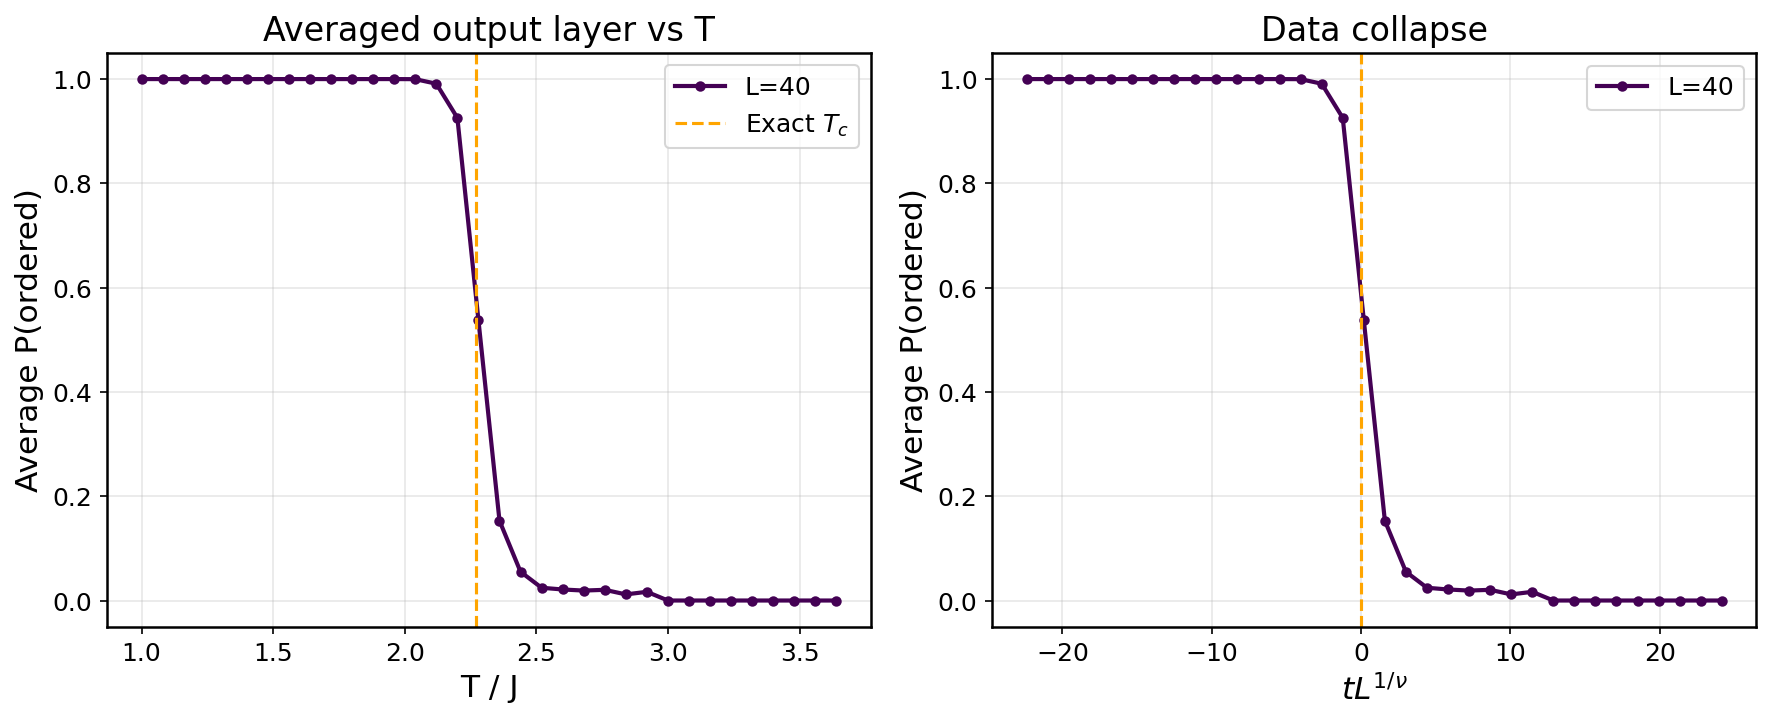

In [60]:
epochs = 35
batch_size = 64
lr = 1e-2
data_dir = r"path_lattice_size_40"


if __name__ == "__main__":
    dataL40 = main(epochs, batch_size, lr, data_dir)
    

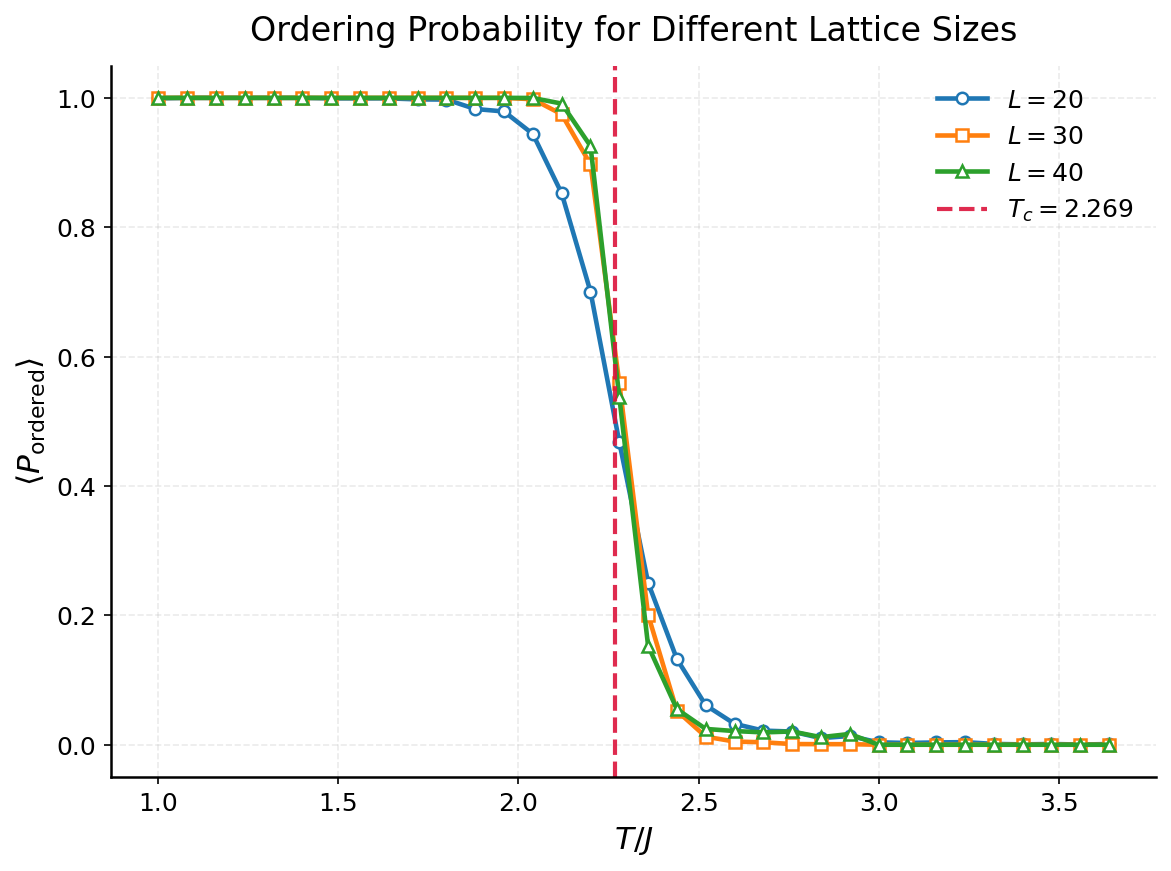

In [66]:


mpl.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 15,
    "axes.titlesize": 16,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,
    "lines.linewidth": 2.0,
    "lines.markersize": 6,
    "figure.dpi": 150,
    "savefig.dpi": 300,
})



all_results = {
    20: dataL20,
    30: dataL30,
    40: dataL40,
}

fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
markers = ['o', 's', '^']

for color, marker, (L, results) in zip(colors, markers, all_results.items()):

    key = f"L{L}"

    T_vals = results["raw_curve_data"][key]["T"]
    P_vals = results["raw_curve_data"][key]["P_ordered"]

    ax.plot(
        T_vals,
        P_vals,
        marker=marker,
        linestyle='-',
        color=color,
        linewidth=2.2,
        markersize=5.5,
        markerfacecolor='white',
        markeredgewidth=1.2,
        label=fr"$L = {L}$"
    )

Tc_exact = 2.269

ax.axvline(
    Tc_exact,
    color='crimson',
    linestyle='--',
    linewidth=2,
    alpha=0.9,
    label=fr"$T_c = {Tc_exact:.3f}$"
)

ax.set_xlabel(r"$T/J$")
ax.set_ylabel(r"$\langle P_{\mathrm{ordered}} \rangle$")
ax.set_title("Ordering Probability for Different Lattice Sizes", pad=12)

# Cleaner publication-style grid
ax.grid(True, which='major', linestyle='--', alpha=0.25)

# Remove top/right spines for a cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend styling
ax.legend(frameon=False, loc='best')

plt.tight_layout()
plt.show()